# **PROBLEM 2**

In [30]:
import pandas as pd

file_path = '/content/StudentsPerformance.csv'
df1 = pd.read_csv(file_path)
print(df1)


     gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none          72             72         

**PREPROCESSING**

In [31]:

print("\nPreprocessing Stage: Missing values in each column")
print(df1.isnull().sum())


df1.fillna(df1.mean(numeric_only=True), inplace=True)


df1.fillna("Unknown", inplace=True)


df1['overall_avg'] = df1[['math score', 'reading score', 'writing score']].mean(axis=1)

print("\nPreprocessing Stage: DataFrame after handling missing values")
print(df1.head())



Preprocessing Stage: Missing values in each column
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Preprocessing Stage: DataFrame after handling missing values
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69         

**A. V1 — Gender boxplots (math vs reading)**

**A)** These boxplots compare the reading and math performance of male and female students. Overall, the median math results for the sexes are not very different from one another. The median reading scores of girls are generally somewhat higher than those of males. Despite possible small variations in variability, the score distribution is likewise comparable. In both subjects, there are outliers that can impact averages but not medians. According to these visualizations, even though there are minor variations, arithmetic performance is comparable for both sexes, with women slightly outperforming men in reading. Gender does not seem to significantly affect performance in general.

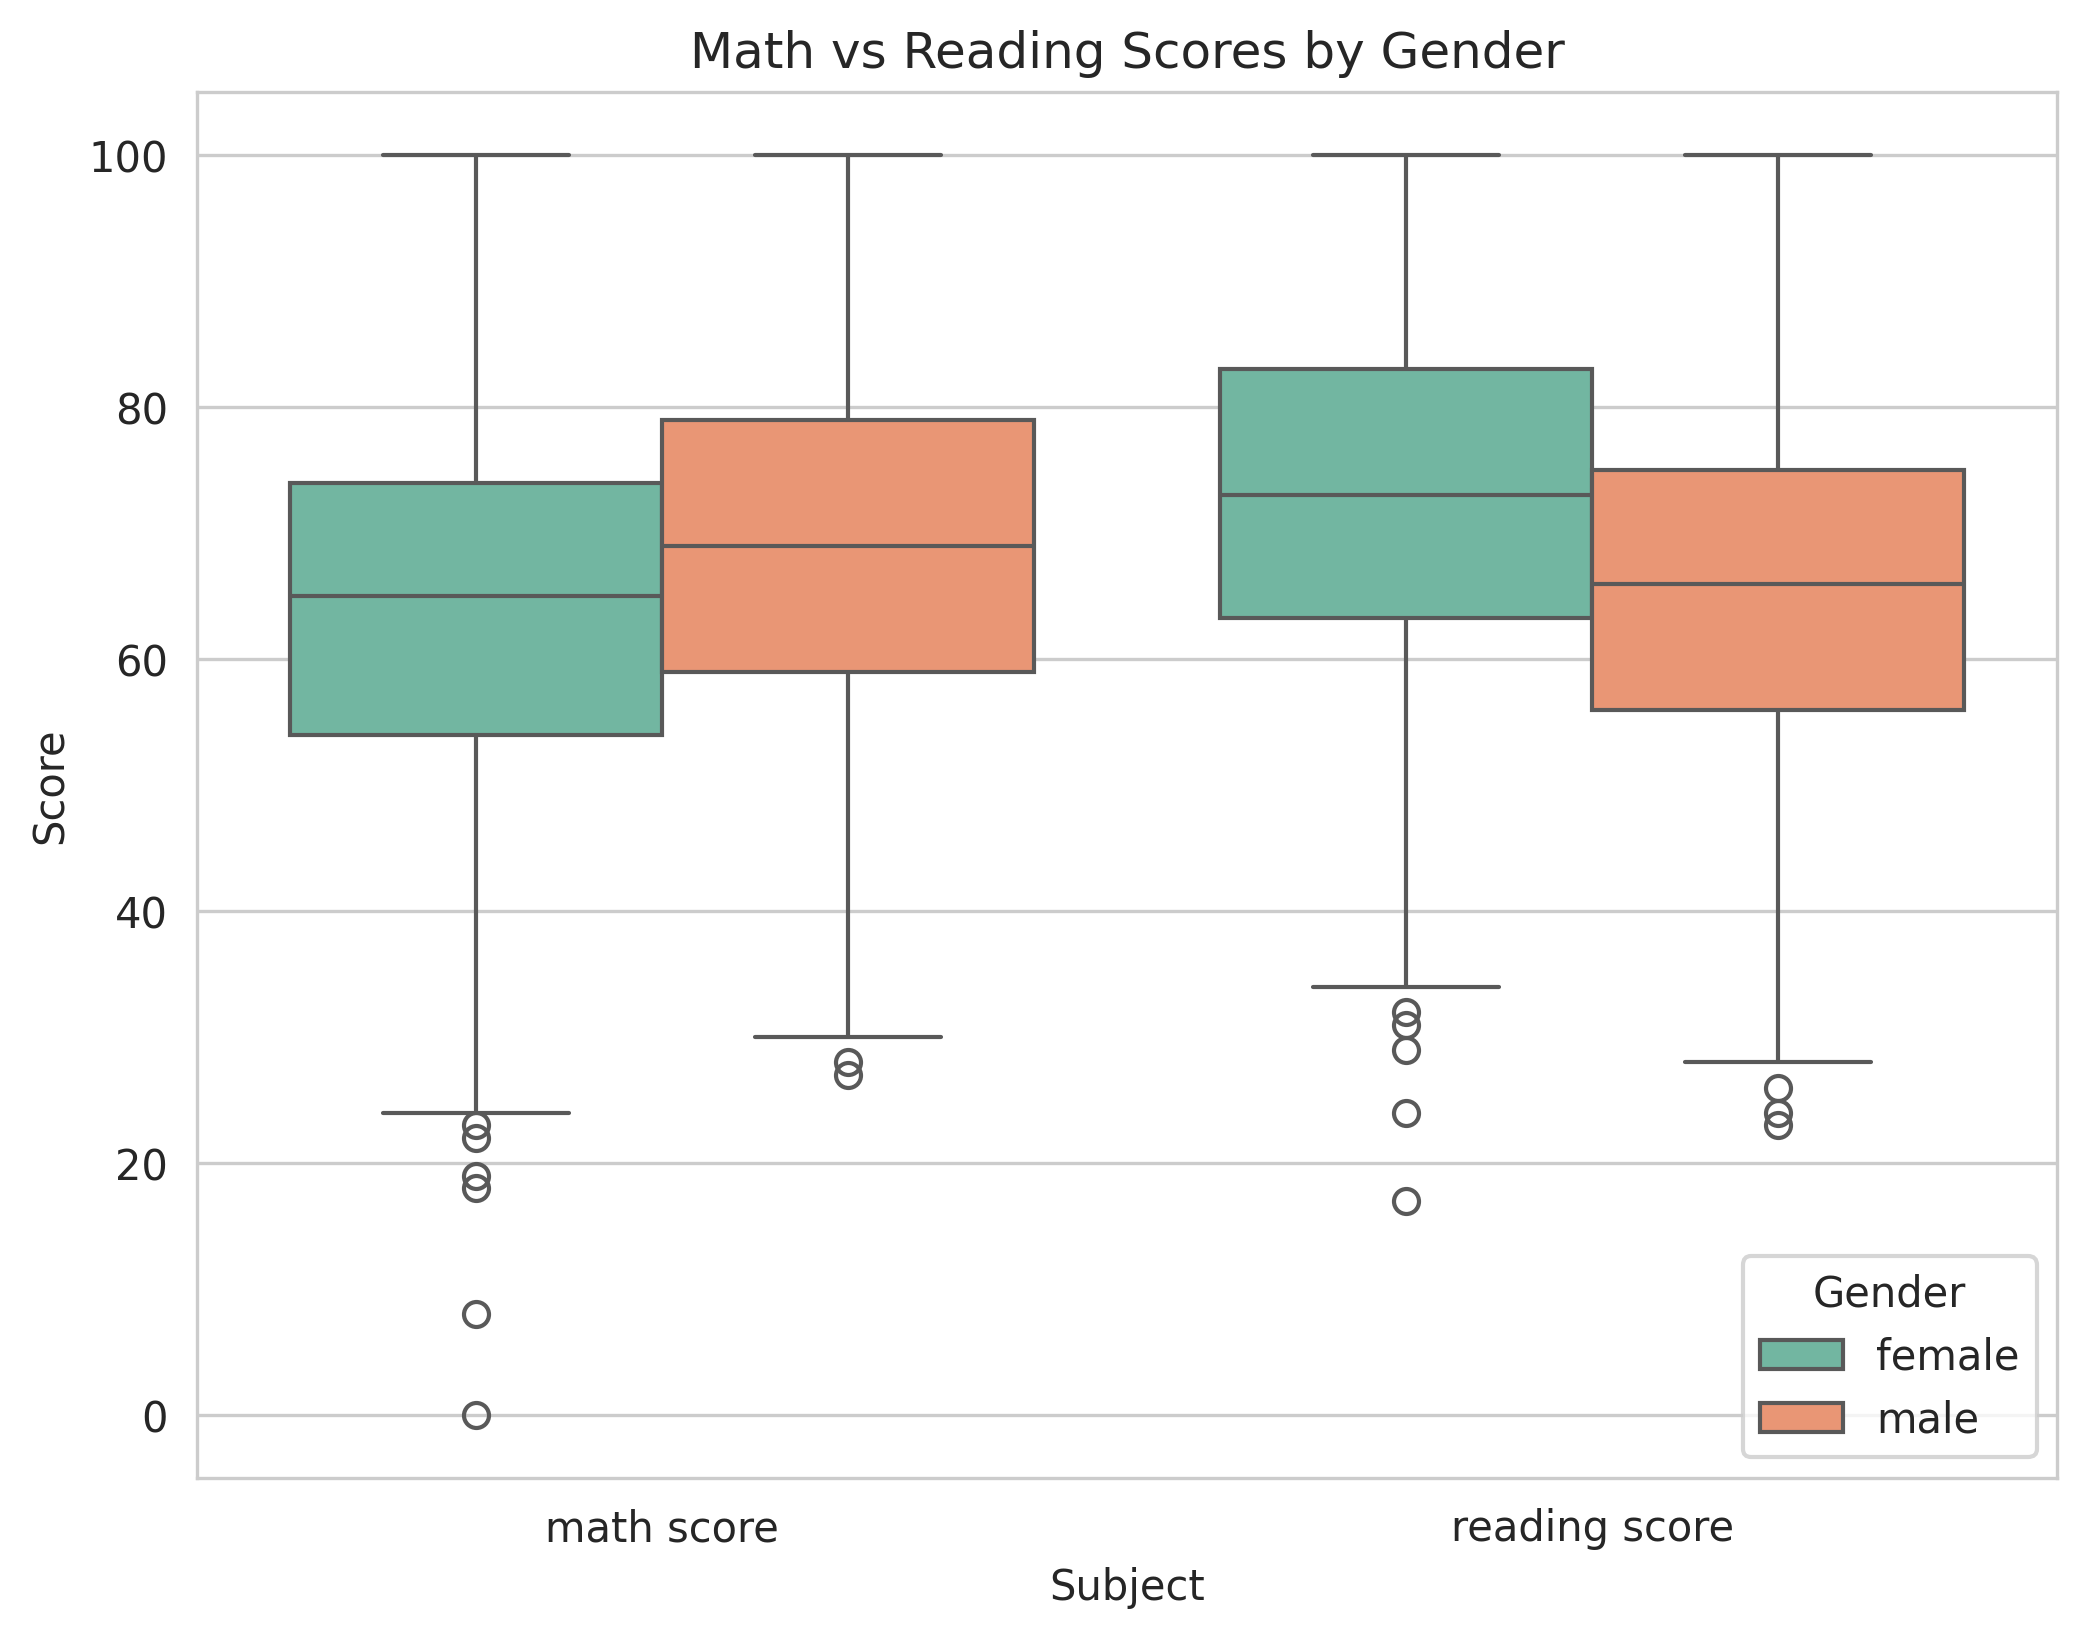

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6), dpi=300)
sns.set_style("whitegrid")


df_melted = df1.melt(
    id_vars="gender",
    value_vars=["math score", "reading score"],
    var_name="Subject",
    value_name="Score"
)


sns.boxplot(
    x="Subject",
    y="Score",
    hue="gender",
    data=df_melted,
    palette="Set2"
)


plt.title("Math vs Reading Scores by Gender")
plt.xlabel("Subject")
plt.ylabel("Score")
plt.legend(title="Gender")
plt.xticks(rotation=0)


plt.show()




**B. V2 — Test prep impact on math**

**A)** Math scores are often higher for students who took the test preparation course than for those who did not. The figures demonstrate that the completed group's median math score is higher than the non-completed group's median. Additionally, the completed group's score distribution is marginally tighter, suggesting more reliable performance. Although there are outliers in both categories, the course-completion rate is higher generally. This implies that taking the test preparation course could improve math performance. However, scores may also be impacted by other elements including past knowledge or study habits. All things considered, taking the test preparation course seems to improve math proficiency.

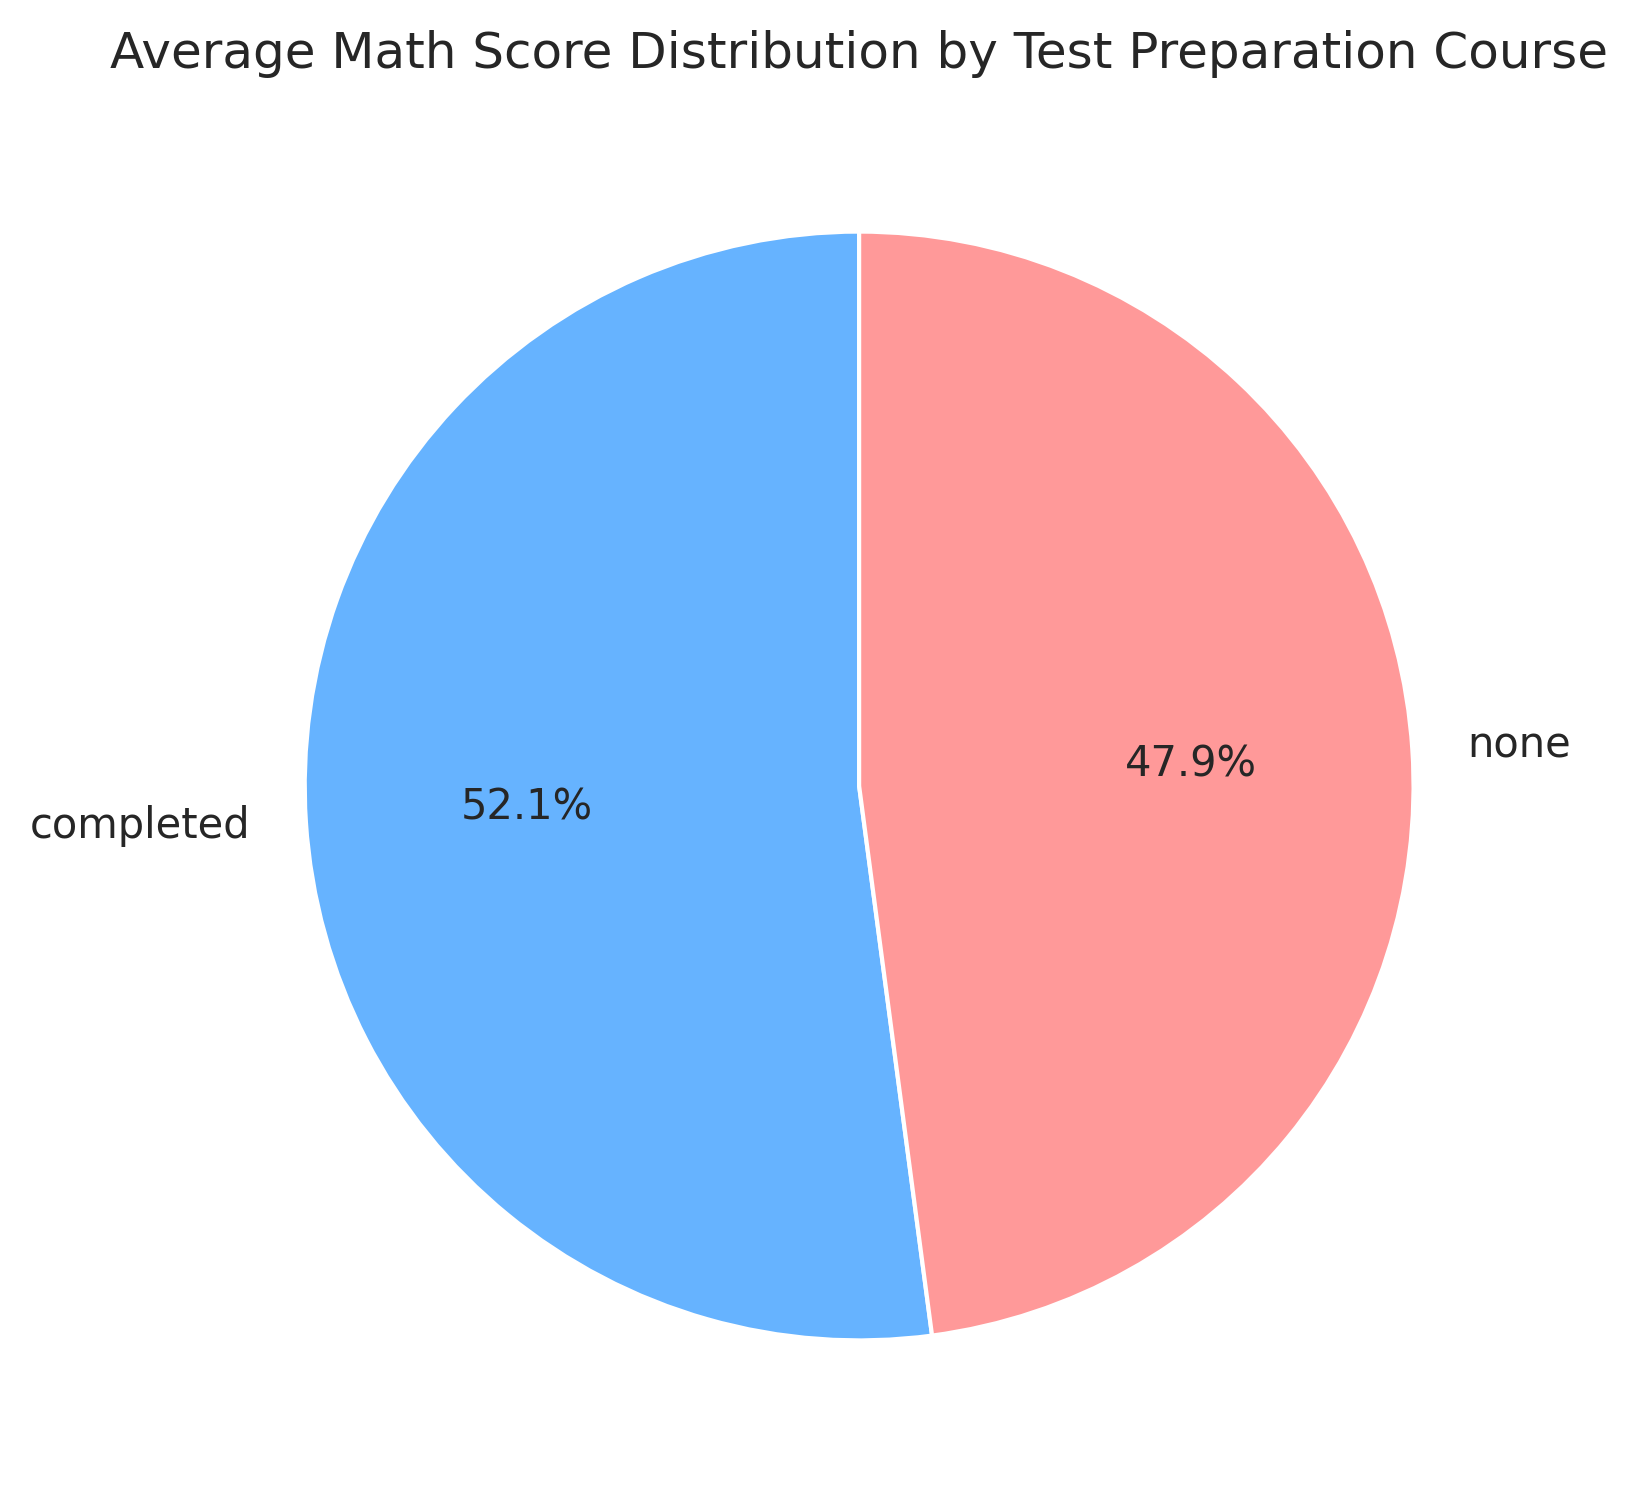

In [35]:
math_means = df1.groupby("test preparation course")["math score"].mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=300)
plt.pie(
    math_means,
    labels=math_means.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#66b3ff", "#ff9999"]
)
plt.title("Average Math Score Distribution by Test Preparation Course")
plt.show()







**C. V3 — Lunch type and average performance**

**A)** According to the grouped bar chart, students who receive a regular lunch often score higher overall than those who receive a free or reduced lunch. This trend is consistent across writing, reading, and math scores. The disparity can be due to socioeconomic conditions, access to educational resources, or the impact of nutrition. Although the score distributions still overlap, students who receive free or reduced lunches do somewhat worse on average. Although there is a correlation between lunch style and results, performance differences are not always the result. Other elements might also be involved, such the school atmosphere or family support.

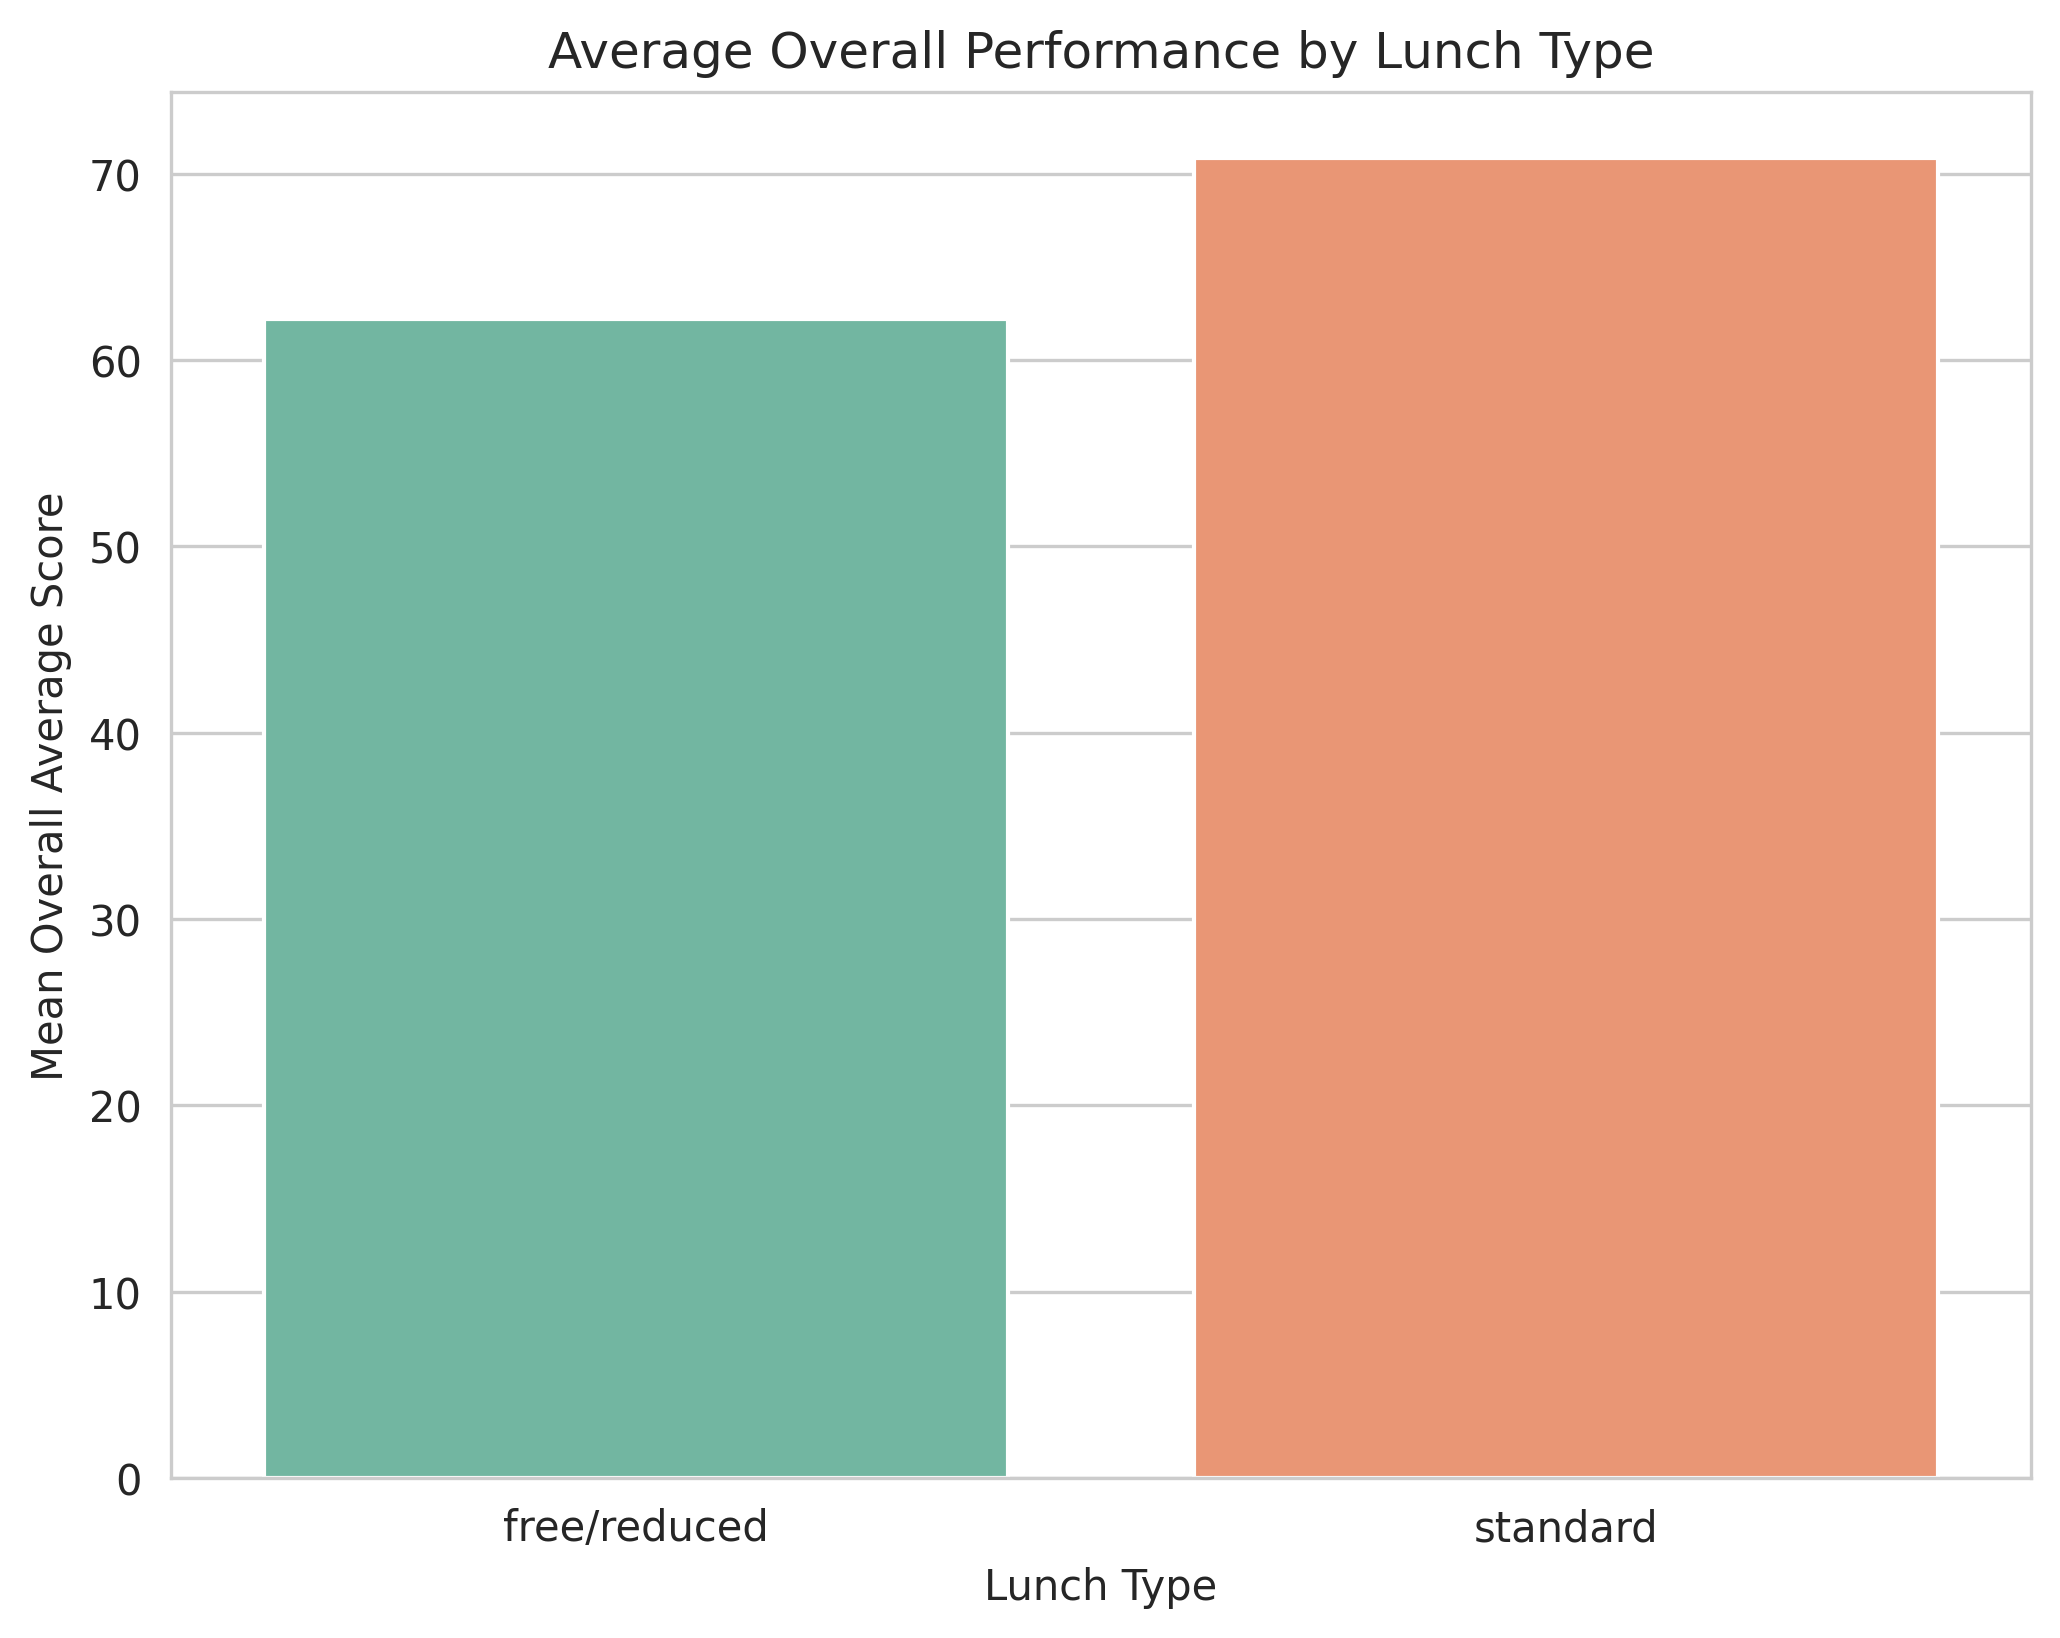

In [36]:



df1["overall_avg"] = df1[["math score", "reading score", "writing score"]].mean(axis=1)


lunch_means = df1.groupby("lunch")["overall_avg"].mean().reset_index()


plt.figure(figsize=(8, 6), dpi=300)
sns.set_style("whitegrid")

sns.barplot(
    x="lunch",
    y="overall_avg",
    data=lunch_means,
    hue="lunch",
    dodge=False,
    palette="Set2",
    legend=False
)

plt.title("Average Overall Performance by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Mean Overall Average Score")
plt.xticks(rotation=0)

plt.show()


**D. V4 — Subject correlations**

**A)** The correlation heatmap shows that math, reading, and writing scores are strongly positively correlated. This means that students who do well in one subject are likely to do well in the others. The coefficients are close to 1, indicating very strong associations. Reading and writing scores often show the highest correlation, while math correlates slightly less but still strongly. This suggests that overall academic ability influences performance across all subjects. The heatmap makes it easy to see which pairs of subjects are most closely related. Overall, the subjects move together consistently for most students.

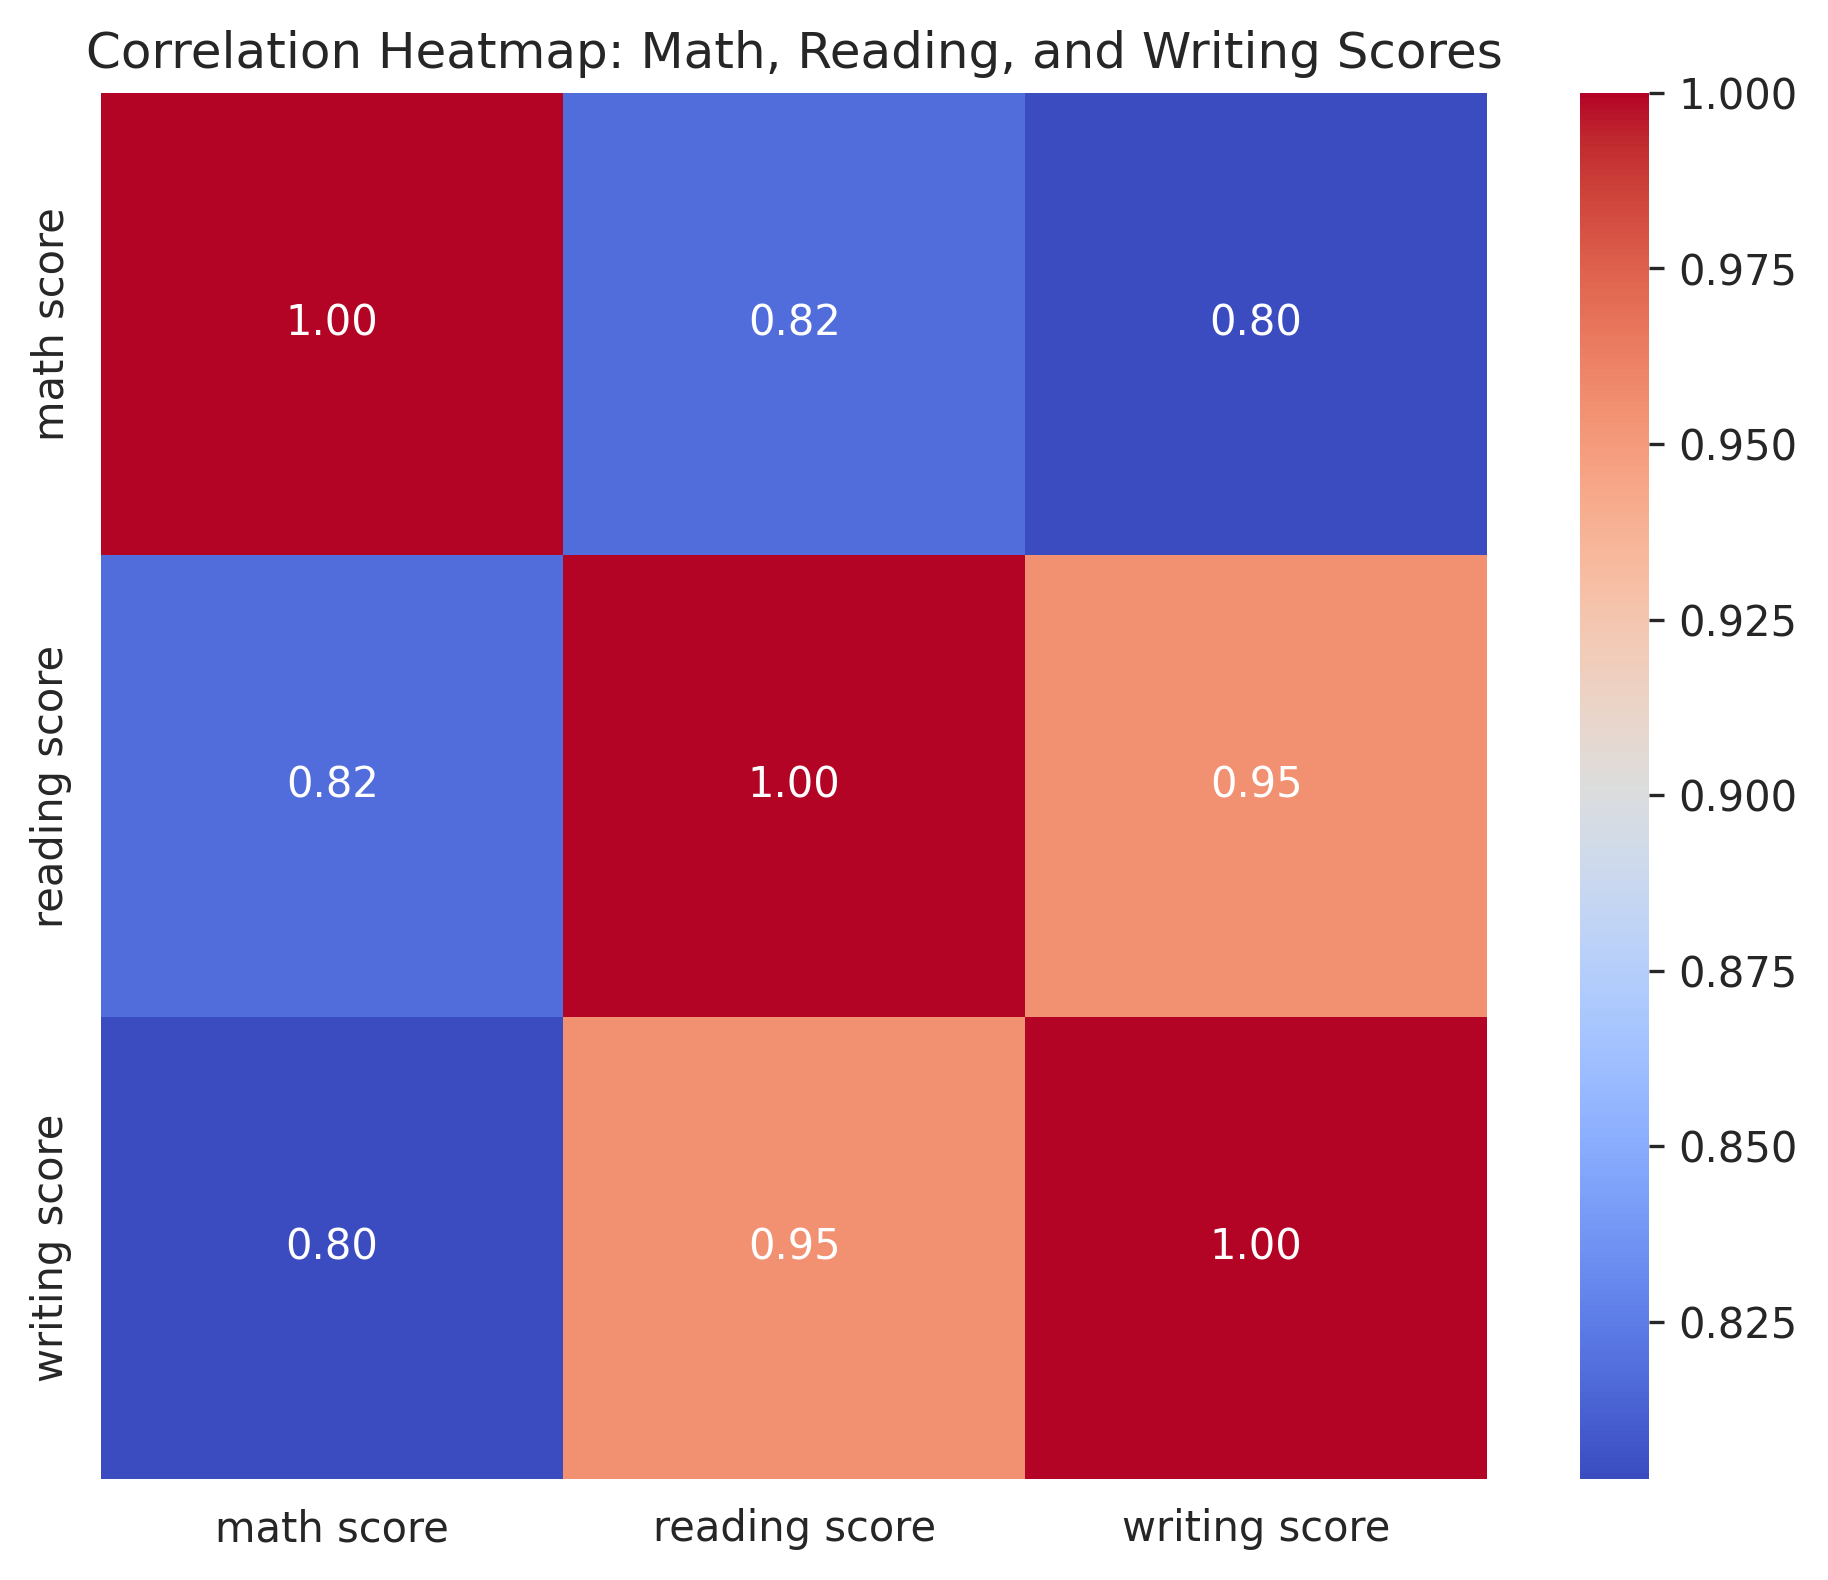

In [37]:

corr = df1[["math score", "reading score", "writing score"]].corr()


plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    cbar=True,
    square=True
)

plt.title("Correlation Heatmap: Math, Reading, and Writing Scores")
plt.show()


**E. V5 — Math vs reading with trend lines by test prep**

**A)** The scatter plot with trend lines shows a positive relationship between math and reading scores. Students with higher reading scores generally have higher math scores. When separating by test preparation course, both groups show a positive slope, but the slope for students who completed the course may be slightly steeper. This suggests that test prep helps students improve math scores relative to reading. The points are somewhat spread, but the trend lines clearly indicate a positive association. Overall, math and reading scores are strongly related, and completing the test prep course appears to slightly enhance this relationship.

**b)**

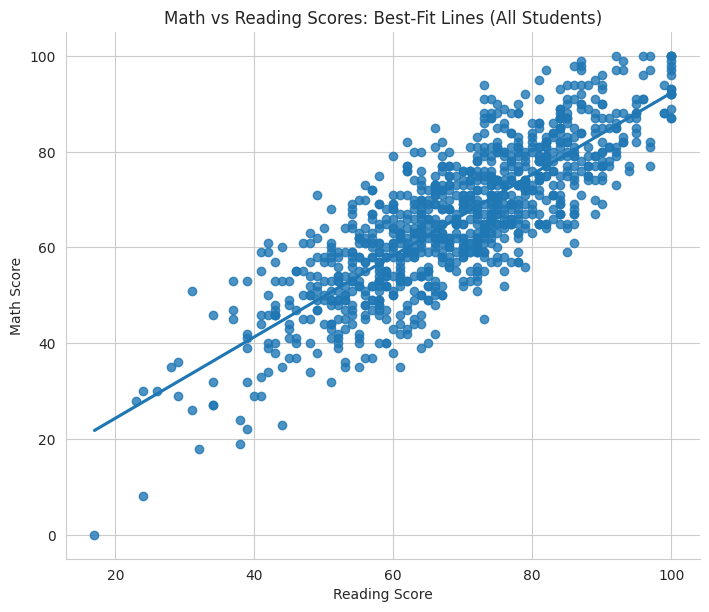

In [38]:

sns.lmplot(
    x="reading score",
    y="math score",
    hue=None,  # no color grouping yet
    data=df1,
    height=6,
    aspect=1.2,
    ci=None
)

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Math vs Reading Scores: Best-Fit Lines (All Students)")
plt.show()


**c)**

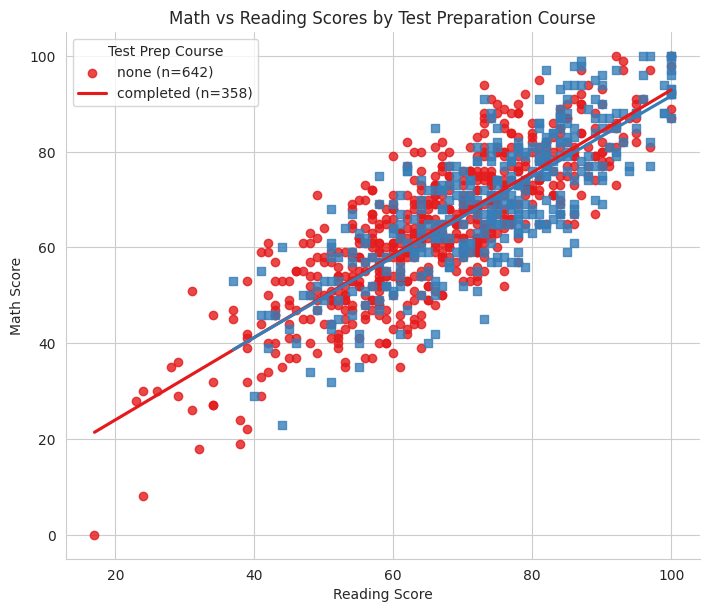

In [39]:

counts = df1["test preparation course"].value_counts()
labels = [f"{grp} (n={counts[grp]})" for grp in counts.index]


sns.lmplot(
    x="reading score",
    y="math score",
    hue="test preparation course",
    data=df1,
    height=6,
    aspect=1.2,
    markers=["o", "s"],
    palette="Set1",
    ci=None,
    legend=False
)

plt.xlabel("Reading Score")
plt.ylabel("Math Score")
plt.title("Math vs Reading Scores by Test Preparation Course")

plt.legend(title="Test Prep Course", labels=labels, loc="best")

plt.show()
